# 04 — Geo-SimCLR pre-training

This notebook trains the headline encoder of the project: a ResNet-18 SimCLR variant with **temporal positive pairs** (same `(fips, grid_idx)` at adjacent biweeks). The frozen encoder is consumed by `05_extract_and_probe.ipynb` for the corn-yield evaluation.

**Purpose / inputs / outputs / runtime**

- **Purpose:** pre-train a 512-d ResNet-18 encoder via NT-Xent on the seven-state CropNet AG imagery. The temporal-positive recipe replaces SimCLR's two-augmentations-of-one-image positive with same-field-different-biweek pairs, so the representation is encouraged to be invariant to short-term weather and remain sensitive to canopy state.
- **Inputs:** `data/processed/county_index.parquet` (tile index from notebook 02), `data/processed/crd_lookup.parquet` (for CRD-balanced anchor sampling), and the raw AG HDF5s under `data/raw/cropnet/Sentinel-2 Imagery/data/AG/...`.
- **Outputs:** per-epoch full-state checkpoints in `models/geo_simclr_resnet18/checkpoints/`, the best-loss encoder + projector at `models/geo_simclr_resnet18/geo_simclr_resnet18_best.pt`, the per-epoch training log at `models/geo_simclr_resnet18/training_log.parquet`, and the per-band normalisation stats at `models/geo_simclr_resnet18/band_stats.json`.
- **Runtime:** **GPU required for production**. The headline run was on **2 RTX 5000s with AMP and DataParallel**, batch size 1024, for 50 epochs (~5 hours total). Set `DEBUG = True` in cell 1 to run a tiny 2-epoch / 1000-anchor smoke test on a laptop CPU in 5–10 min — useful only for catching code bugs before the GPU run.

**Headline design choices**

| Component | Choice |
|---|---|
| Backbone | ResNet-18 from scratch (no ImageNet weights), 3-channel AG input |
| Projection head | 2-layer MLP $512 \to 256 \to 128$ with BatchNorm + ReLU; $\ell_2$-normalised output. Discarded after pre-training. |
| Loss | NT-Xent on $\ell_2$-normalised projections, in-batch negatives, temperature $\tau = 0.2$. |
| Optimizer | AdamW lr $10^{-3}$, weight decay $10^{-4}$. 5-epoch linear warm-up from lr/100 → lr, then cosine annealing to $\eta_\text{min} = 10^{-6}$ over the remaining 45 epochs. |
| Batch size | 1024 effective on 2 GPUs via DataParallel + AMP (32 in CPU-debug mode). |
| Mixed precision | `torch.amp.autocast("cuda")` + `GradScaler`. |
| Epochs | 50 (production); 2 (debug). |
| Positive pair | Same `(fips, year, grid_idx)`, biweek $t \pm 1$, both inside the growing season. |
| Negatives | All other tiles in the batch. Anchors are drawn with `WeightedRandomSampler` weighted as $1/(\#\text{anchors per CRD})$ so batches are agro-climatically diverse on average. |
| Augmentations (per view, independent) | hflip 0.5; vflip 0.5; rot90 with $k\!\in\!\{1,2,3\}$ p=0.75; random crop side $\in [160, 208]$ → resize 224; sharpness $\times 2.0$ p=0.5; per-band intensity jitter $\times U[0.8, 1.2]$ p=0.8; per-band Gaussian noise $\sigma = 0.02$; per-band $z$-score normalisation. **No** spectral dropout, **no** RGB colour jitter, **no** mixup. |
| Train scope | 2017–2021 only (2022 strictly held out so it never leaks into the time-split test set in notebook 05). |

A short summary of how we got to these numbers: the first attempt used batch 256, lr 3e-4, $\tau = 0.5$ and finished with mean positive-pair cosine similarity climbing to ~0.95 — a textbook signal that the temporal-positive task was too easy and the representation was partially collapsing. We then bumped to batch 1024 (linear-scaling lr to $10^{-3}$), tightened temperature to 0.2, tightened the random-crop range to 160–208 px, and added a per-band intensity-jitter augmentation. The final-run hyperparameters in the cells below reflect the bumped configuration. The collapse is reduced (effective rank rises from ~35/512 to 82/512) but not eliminated, and is documented honestly in `06_visualize.ipynb`.

```mermaid
flowchart TB
    subgraph Pipeline [Per training step]
        A["Anchor: tile (fips, year, t, grid_idx)"] --> Aug1[Augment 1: flip + rot90 + crop + sharpness + jitter + noise]
        Aug1 --> E1["ResNet-18 (shared weights)"]
        E1 --> Em1["512-d backbone embedding"]
        Em1 --> Pr1["Projector MLP (512 -> 256 -> 128) + L2-norm"]
        Pr1 --> Z1["z1"]
        AT["Positive: same (fips, year, grid), biweek t+/-1"] --> Aug2[Augment 2 -- independent draw]
        Aug2 --> E2["ResNet-18 (same weights)"]
        E2 --> Em2["512-d backbone embedding"]
        Em2 --> Pr2["Projector MLP (same weights) + L2-norm"]
        Pr2 --> Z2["z2"]
        Z1 --> NTXent["NT-Xent: pull (z1, z2) together, push other 2N-2 batch members apart"]
        Z2 --> NTXent
        NTXent --> Adam[AdamW backprop -- updates encoder + projector]
    end
```

**Outputs on disk (consumed by `05_extract_and_probe.ipynb`)**

| File | Description |
|---|---|
| `models/geo_simclr_resnet18/checkpoints/...epoch_NNN.pt` | per-epoch full-state checkpoints (model + optimizer + scheduler + cumulative log + AMP scaler) for auto-resume |
| `models/geo_simclr_resnet18/geo_simclr_resnet18_best.pt` | best-loss encoder + projector state plus band stats and config snapshot |
| `models/geo_simclr_resnet18/training_log.parquet` | per-epoch loss, $\|h\|$, mean positive-pair cosine similarity, learning rate, elapsed seconds |
| `models/geo_simclr_resnet18/band_stats.json` | per-band mean/std computed on a 200-anchor sample of the training tiles; the same stats are re-applied at inference |

In [1]:
"""
Imports + paths + config.

DEBUG flag at the top:
  True  -> tiny local CPU smoke test (2 epochs, batch 32, 1000 anchors). 5-10 min on a laptop CPU.
  False -> production GPU run (50 epochs, batch 1024, all anchors). About 5 hours on 2 GPUs.
"""
DEBUG = False

import os
import re
import time
import json
from pathlib import Path
import warnings
# Suppress the `torch.cuda.amp.autocast(args...)` deprecation FutureWarning that DataParallel
# emits from its own internal code (parallel_apply.py). It's a PyTorch upstream issue we can't
# fix from user-space; our own AMP usage below uses the new `torch.amp` API.
warnings.filterwarnings("ignore", message=r".*torch\.cuda\.amp\.autocast.*", category=FutureWarning)

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms

# ---------------- Paths -----------------
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW = ROOT / "data" / "raw" / "cropnet"
DATA_PROC = ROOT / "data" / "processed"
MODELS_DIR = ROOT / "models"
RESULTS_DIR = ROOT / "results"
# All Geo-SimCLR artifacts (best.pt, band_stats, log, per-epoch checkpoints) live in this folder.
SSL_MODEL_DIR = MODELS_DIR / "geo_simclr_resnet18"
CKPT_SUBDIR = SSL_MODEL_DIR / "checkpoints"
SSL_MODEL_DIR.mkdir(parents=True, exist_ok=True)
CKPT_SUBDIR.mkdir(parents=True, exist_ok=True)

# Inputs
COUNTY_INDEX_PATH = DATA_PROC / "county_index.parquet"
CRD_PATH = DATA_PROC / "crd_lookup.parquet"
YIELD_PATH = DATA_PROC / "yield_county_year.parquet"
PHEN_STAGE_PATH = DATA_PROC / "phen_stage_lookup.parquet"

# Outputs
NORM_STATS_PATH = SSL_MODEL_DIR / "band_stats.json"
TRAINING_LOG_PATH = SSL_MODEL_DIR / "training_log.parquet"
BEST_MODEL_PATH = SSL_MODEL_DIR / "geo_simclr_resnet18_best.pt"

# ---------------- Hyperparameters -----------------
class Cfg:
    # Data scope
    TRAIN_YEARS = (2017, 2018, 2019, 2020, 2021)  # SSL pretraining excludes 2022 (the time-split test year)
    
    # SSL training
    BACKBONE = "resnet18"
    EMBED_DIM = 512        # ResNet-18 backbone output
    PROJ_HIDDEN = 256
    PROJ_DIM = 128
    TEMPERATURE = 0.2      # NT-Xent temperature; the first attempt at 0.5 saw mean positive-pair
                           # cosine sim climb to ~0.95 (a soft sign of partial collapse), so we
                           # tightened it to give a sharper loss / harder push on negatives.

    # Optimization
    # lr was linearly scaled from 3e-4 at batch 256 to 1e-3 at batch 1024 (Goyal et al. 2017,
    # "Accurate Large Minibatch SGD"). With WARMUP_EPOCHS=5 the effective start LR is 1e-5
    # so instability at the larger lr is unlikely.
    LR = 1e-3
    WEIGHT_DECAY = 1e-4
    WARMUP_EPOCHS = 5      # linear LR warmup from LR/100 -> LR over the first 5 epochs, then cosine.

    # Augmentation
    CROP_MIN = 160          # 160 px = 6.4 km of the 9 km tile (51% area). Aggressive lower bound.
    CROP_MAX = 208          # 208 px = 8.4 km (92% area). Upper bound preserves enough field-level context.
    NOISE_SIGMA = 0.02      # per-band Gaussian noise sigma in normalized [0, 1] space
    BAND_JITTER_LO = 0.8    # per-band intensity jitter range [BAND_JITTER_LO, BAND_JITTER_HI]
    BAND_JITTER_HI = 1.2
    BAND_JITTER_P  = 0.8    # probability of applying the jitter per view

    # Mixed precision: torch.amp.autocast("cuda") + GradScaler. ~2-3x speedup on GPU and roughly
    # halves activation memory, while matching fp32 training accuracy for NT-Xent. Disabled on CPU.
    USE_AMP = True
    
    # Production / debug splits
    if DEBUG:
        DEVICE = "cpu"
        BATCH_SIZE = 32
        NUM_WORKERS = 0
        EPOCHS = 2
        N_ANCHORS_PER_EPOCH = 200    # tiny subsample for fast iteration
        STATES_FILTER = ("IA",)       # only IA tiles
        CKPT_EVERY = 1
        TAG = "debug"
    else:
        # Production config used for the headline 7-state run (~5 hours on 2 GPUs).
        #
        # NUM_WORKERS guidance: 8 is the stable value here. We saw a CPU-RAM blow-up with
        # NUM_WORKERS=16 + persistent_workers=True + pinned memory (kernel OOM on epoch 1).
        # The recipe that works is NUM_WORKERS=8 + persistent_workers=False + h5py chunk cache
        # 32 MB (set in cell 6's _get_handle). If you OOM, reduce NUM_WORKERS before batch size.
        #
        # BATCH_SIZE guidance: 1024 effective via DataParallel + AMP. AMP halves activation
        # memory so 1024 fits comfortably (around 8-12 GB per GPU for ResNet-18 + projector
        # + two views at batch 512/GPU). More in-batch negatives means a harder SimCLR task
        # and roughly a 30% walltime reduction vs batch 512. LR was linear-scaled 256->1024.
        # Per-epoch wall time at this config: ~5-7 min.
        DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
        MULTI_GPU = True         # use both GPUs via DataParallel
        BATCH_SIZE = 1024        # global batch size; DataParallel splits across the GPUs
        NUM_WORKERS = 8
        EPOCHS = 50
        N_ANCHORS_PER_EPOCH = None    # use all (None = iterate every anchor once per epoch)
        STATES_FILTER = ("IA", "IL", "IN", "MN", "NE", "OH", "SD")  # full seven-state scope
        CKPT_EVERY = 1                # save every epoch (cheap)
        TAG = "prod"

cfg = Cfg()

print(f"Mode      : {'DEBUG' if DEBUG else 'PRODUCTION'}")
print(f"Device    : {cfg.DEVICE}")
if not DEBUG and torch.cuda.is_available():
    print(f"  visible GPUs   : {torch.cuda.device_count()}")
    print(f"  MULTI_GPU flag : {getattr(cfg, 'MULTI_GPU', False)}")
print(f"Batch size: {cfg.BATCH_SIZE}")
print(f"Epochs    : {cfg.EPOCHS}")
print(f"Workers   : {cfg.NUM_WORKERS}")
print(f"States    : {cfg.STATES_FILTER}")
print(f"Crop      : [{cfg.CROP_MIN}, {cfg.CROP_MAX}] px from 224  (min coverage {cfg.CROP_MIN/224*9:.1f}/9 km)")
print(f"Temp/LR   : {cfg.TEMPERATURE} / {cfg.LR}  (warmup {getattr(cfg, 'WARMUP_EPOCHS', 0)} ep)")
print(f"AMP       : {getattr(cfg, 'USE_AMP', False)} (torch.amp.autocast + GradScaler)")
print(f"SSL years : {cfg.TRAIN_YEARS}  (excludes 2022 = time-split test year)")
print(f"SSL artifacts -> : {SSL_MODEL_DIR}")

# Sanity: required inputs from earlier notebooks
for p in [COUNTY_INDEX_PATH, CRD_PATH]:
    assert p.exists(), f"Missing {p} -- run notebook 02 first."

# Reproducibility
torch.manual_seed(0)
np.random.seed(0)

Mode      : PRODUCTION
Device    : cuda
  visible GPUs   : 2
  MULTI_GPU flag : True
Batch size: 1024
Epochs    : 50
Workers   : 8
States    : ('IA', 'IL', 'IN', 'MN', 'NE', 'OH', 'SD')
Crop      : [160, 208] px from 224  (min coverage 6.4/9 km)
Temp/LR   : 0.2 / 0.001  (warmup 5 ep)
AMP       : True (torch.amp.autocast + GradScaler)
SSL years : (2017, 2018, 2019, 2020, 2021)  (excludes 2022 = time-split test year)
SSL artifacts -> : /nfs/roberts/project/cpsc4520/cpsc4520_ipp3/project-geospatial/models/geo_simclr_resnet18


## 1. Build the per-tile training index + adjacent-biweek pairs

`county_index.parquet` (from notebook 02) has one row per `(state, fips, year, biweek)` with `n_grids` indicating how many 224x224 tiles that county-biweek contains. We need to expand it so each row is one *individual tile* `(state, fips, year, biweek, grid_idx)`. We also pre-compute the **valid adjacent-biweek partner(s)** for each tile, which the dataset class will randomly sample from at training time.

A tile's valid partners are limited:

- Must be in the **same** `(state, fips, year, grid_idx)` (same physical 9km square, same year — no winter crossing).
- Must be in the same growing-season biweek list (Apr 1 ... Sep 15).
- For boundary biweeks (Apr 1 has no `t-1`, Sep 15 has no `t+1`), only the available direction is valid.

We filter to `cfg.TRAIN_YEARS` (2017-2021) and `cfg.STATES_FILTER`. The held-out 2022 tiles are **never seen** during SSL pretraining.

In [2]:
"""
Cell 2 — Build the per-tile anchor list with valid adjacent-biweek partners.

Subtle correctness point: each tile lives in a specific HDF5 file (one per state-year-quarter).
The (Jun 15 <-> Jul 1) adjacent-biweek pair crosses the Q2/Q3 file boundary. We MUST track
which file holds each (fips, year, biweek) so the dataset class loads the partner from the
correct file. We pre-build a (fips, year, biweek) -> h5_path lookup for this.
"""
ci = pd.read_parquet(COUNTY_INDEX_PATH)
print(f"county_index rows                  : {len(ci):,}")

# Cross-check that county_index has every state in cfg.STATES_FILTER. A stale parquet that
# silently covers fewer states than the filter expects would otherwise produce a smaller-scope
# training run than intended without any error message.
_ci_states = sorted(ci["state"].unique().tolist())
_missing_states = sorted(set(cfg.STATES_FILTER) - set(_ci_states))
_extra_states   = sorted(set(_ci_states) - set(cfg.STATES_FILTER))
print(f"county_index states                : {_ci_states}")
print(f"cfg.STATES_FILTER                  : {sorted(cfg.STATES_FILTER)}")
if _missing_states:
    print()
    print("=" * 80)
    print(f"[ERROR] county_index.parquet is MISSING {len(_missing_states)} state(s): {_missing_states}")
    print(f"        These states are in cfg.STATES_FILTER but not in county_index.")
    print(f"        Likely cause: a stale county_index.parquet from an earlier scope.")
    print(f"        Fix: regenerate county_index.parquet via notebook 02 with the current scope.")
    print(f"        NOT stopping training -- just warning. Training will proceed on available data.")
    print("=" * 80)
    print()
if _extra_states:
    print(f"[info] county_index has {_extra_states} not in STATES_FILTER -- they'll be filtered out.")

ci_train = ci[
    (ci["year"].astype(int).isin(cfg.TRAIN_YEARS)) &
    (ci["state"].isin(cfg.STATES_FILTER))
].copy()
print(f"after year + state filter         : {len(ci_train):,}")
print(f"  per-state county-biweek rows    : {ci_train.groupby('state').size().to_dict()}")

# Lookup: (fips, year, biweek) -> h5_path (resolves cross-quarter partner files correctly)
biweek_to_h5 = ci_train.set_index(
    [ci_train["fips"].astype(int), ci_train["year"].astype(int), ci_train["biweek"]]
)["h5_path"].to_dict()
print(f"biweek->h5 lookup entries         : {len(biweek_to_h5):,}")

# For each (fips, year) sort the available biweeks chronologically; partners = adjacent in that list
print("\nComputing valid adjacent partners per (fips, year)...")
neighbor_lookup = {}
for (fips, year), g in tqdm(
    ci_train.groupby(["fips", "year"]),
    total=ci_train.groupby(["fips", "year"]).ngroups,
):
    bws = sorted(g["biweek"].tolist())
    for i, bw in enumerate(bws):
        partners = []
        if i > 0:
            partners.append(bws[i - 1])
        if i < len(bws) - 1:
            partners.append(bws[i + 1])
        neighbor_lookup[(int(fips), int(year), bw)] = partners

# Expand county_index rows -> one row per (state, fips, year, biweek, grid_idx)
# Each anchor record stores BOTH the anchor's h5_path AND the partners' h5_paths so the dataset
# class doesn't need to do per-call lookups.
print("\nExpanding county-biweek rows -> per-tile anchor list...")
anchor_records = []
for _, row in tqdm(ci_train.iterrows(), total=len(ci_train)):
    fips = int(row["fips"])
    year = int(row["year"])
    biweek = row["biweek"]
    n_grids = int(row["n_grids"])
    h5_path = row["h5_path"]
    partners = neighbor_lookup.get((fips, year, biweek), [])
    if not partners:
        continue
    # Resolve partner h5_paths
    partner_paths = [biweek_to_h5.get((fips, year, p), None) for p in partners]
    # Drop partners whose h5_path is missing (shouldn't happen for our scope, but safe)
    valid = [(p, pp) for p, pp in zip(partners, partner_paths) if pp is not None]
    if not valid:
        continue
    partners_resolved = [p for p, _ in valid]
    partner_paths = [pp for _, pp in valid]

    for grid_idx in range(n_grids):
        anchor_records.append({
            "state": row["state"],
            "fips": fips,
            "year": year,
            "biweek": biweek,
            "grid_idx": grid_idx,
            "n_grids": n_grids,
            "h5_path": h5_path,
            "partners": partners_resolved,
            "partner_paths": partner_paths,
        })
anchors_df = pd.DataFrame(anchor_records)
print(f"\nTotal anchors (tile-grids with at least one partner): {len(anchors_df):,}")
print(f"  by state: {anchors_df.groupby('state').size().to_dict()}")
print(f"  by year : {anchors_df.groupby('year').size().to_dict()}")
print(f"  median partners per anchor: {anchors_df['partners'].apply(len).median():.0f}")
print(f"  fraction with both partners (interior biweeks): {(anchors_df['partners'].apply(len) == 2).mean():.2%}")
print(f"  fraction with one partner   (boundary biweeks): {(anchors_df['partners'].apply(len) == 1).mean():.2%}")
# Sanity: how many anchors have a cross-quarter partner?
cross_q = anchors_df.apply(lambda r: any(pp != r["h5_path"] for pp in r["partner_paths"]), axis=1)
print(f"  anchors with at least one cross-quarter partner: {cross_q.sum():,}  ({cross_q.mean():.2%})")

county_index rows                  : 44,140
county_index states                : ['IA', 'IL', 'IN', 'MN', 'NE', 'OH', 'SD']
cfg.STATES_FILTER                  : ['IA', 'IL', 'IN', 'MN', 'NE', 'OH', 'SD']
after year + state filter         : 36,856
  per-state county-biweek rows    : {'IA': 5940, 'IL': 6043, 'IN': 5520, 'MN': 4961, 'NE': 5336, 'OH': 5219, 'SD': 3837}
biweek->h5 lookup entries         : 36,856

Computing valid adjacent partners per (fips, year)...


100%|██████████| 3073/3073 [00:00<00:00, 9330.16it/s] 



Expanding county-biweek rows -> per-tile anchor list...


100%|██████████| 36856/36856 [00:02<00:00, 14344.94it/s]



Total anchors (tile-grids with at least one partner): 711,522
  by state: {'IA': 78120, 'IL': 89022, 'IN': 48480, 'MN': 164515, 'NE': 121728, 'OH': 63950, 'SD': 145707}
  by year : {2017: 140359, 2018: 142848, 2019: 142848, 2020: 142794, 2021: 142673}
  median partners per anchor: 2
  fraction with both partners (interior biweeks): 83.31%
  fraction with one partner   (boundary biweeks): 16.69%
  anchors with at least one cross-quarter partner: 118,516  (16.66%)


In [3]:
"""
Attach CRD ID to each anchor and verify the CRD distribution for sampling.

CRD = Crop Reporting District. We use a state-aware identifier
    crd_id = state_fips * 100 + asd_code
so that cross-state same-direction districts (e.g. IA-NW and IL-NW) get *different* crd_ids —
they are different physical regions despite the shared directional name.

For SSL we want batches to be CRD-diverse so within-batch random negatives are agro-climatically
diverse on average. We achieve this with a `WeightedRandomSampler` weighted so each crd_id gets
roughly equal representation per epoch.
"""
crd = pd.read_parquet(CRD_PATH)
crd["crd_id"] = crd["state_ansi"].astype(int) * 100 + crd["asd_code"].astype(int)
fips_to_crd = crd.set_index("fips")["crd_id"].to_dict()
anchors_df["crd_id"] = anchors_df["fips"].map(fips_to_crd)

# Drop anchors whose fips is missing from crd_lookup.parquet. county_index has 616 counties
# but crd_lookup only 611 (a handful of small / non-standard FIPS lack an ASD assignment in
# CropNet's lookup). Those anchors end up with NaN crd_id and a NaN sample weight, which
# would crash WeightedRandomSampler with "multinomial probability < 0".
n_before = len(anchors_df)
n_no_crd = int(anchors_df["crd_id"].isna().sum())
if n_no_crd > 0:
    missing_fips = sorted(anchors_df.loc[anchors_df["crd_id"].isna(), "fips"].unique().tolist())
    print(f"[warning] {n_no_crd:,} anchors ({n_no_crd/n_before*100:.2f}%) have no CRD mapping "
          f"(their fips not in crd_lookup.parquet).")
    print(f"           Dropping them. Missing FIPS ({len(missing_fips)}): {missing_fips[:10]}"
          f"{'...' if len(missing_fips) > 10 else ''}")
    anchors_df = anchors_df.dropna(subset=["crd_id"]).reset_index(drop=True)
anchors_df["crd_id"] = anchors_df["crd_id"].astype(int)
print(f"Anchors with crd_id: {len(anchors_df):,} (was {n_before:,} before dropna)")
print(f"Unique CRDs in train set: {anchors_df['crd_id'].nunique()}")
print()
print("Anchor count per CRD (top 10):")
print(anchors_df.groupby("crd_id").size().sort_values(ascending=False).head(10).to_string())

# Compute CRD-balanced sampling weights: weight ∝ 1 / count_per_crd
# Each CRD then has equal expected representation per epoch.
crd_counts = anchors_df.groupby("crd_id").size()
anchors_df["sample_weight"] = anchors_df["crd_id"].map(1.0 / crd_counts)
anchors_df["sample_weight"] /= anchors_df["sample_weight"].sum()  # normalize

# Hard asserts so WeightedRandomSampler never sees NaN/negative/inf weights again.
assert not anchors_df["sample_weight"].isna().any(), "NaN in sample_weight -- CRD map incomplete?"
assert (anchors_df["sample_weight"] >= 0).all(), "Negative sample_weight encountered"
assert np.isfinite(anchors_df["sample_weight"]).all(), "Non-finite sample_weight (inf/-inf)"
print(f"\nSample weights computed. After CRD-balanced weighting, each CRD contributes ~{1 / anchors_df['crd_id'].nunique():.4f} probability per draw.")

[warning] 33,600 anchors (4.72%) have no CRD mapping (their fips not in crd_lookup.parquet).
           Dropping them. Missing FIPS (7): [27077, 27137, 31007, 31009, 31117, 46071, 46117]
Anchors with crd_id: 677,922 (was 711,522 before dropna)
Unique CRDs in train set: 61

Anchor count per CRD (top 10):
crd_id
4610    32340
2720    30523
3120    27060
3110    25200
2710    24900
4640    20400
2750    19920
2760    18240
2740    17532
4680    16084

Sample weights computed. After CRD-balanced weighting, each CRD contributes ~0.0164 probability per draw.


## 2. Augmentations

Recent EO-SSL work (SeCo, GASSL, GeoSSL) shows that safe spatial + mild photometric augmentations work better than aggressive band-level masking on multispectral data. Our pipeline applies, per view, independently:

| Transform | Probability |
|---|---|
| horizontal flip / vertical flip | 0.5 each (satellite imagery has no privileged orientation) |
| rot90 with $k \in \{1, 2, 3\}$ | 0.75 |
| random crop side $\in [160, 208]$ px → resize back to 224 | 1.0 (covers ~6.4–7.4 km of the 9 km tile) |
| random sharpness $\times 2.0$ | 0.5 |
| per-band intensity jitter $\times \mathcal{U}[0.8, 1.2]$ | 0.8 (one scalar per band per view, then clamp to [0, 1]; applied *before* z-score) |
| per-band Gaussian noise $\sigma = 0.02$ | 1.0 (in normalised [0, 1] space; small enough to not destroy the signal but enough to prevent memorising the 5-bin uint8 quantisation) |
| per-band $z$-score normalisation | 1.0 (computed once on a sample of training tiles, then applied last) |

We deliberately leave out three transforms that are common in RGB SimCLR but unhelpful here: **spectral band dropout** (zeroing one of three channels is too destructive), **RGB-flavoured colour jitter** (we have no R/G/B channels — the per-band intensity jitter above is the safe analogue), and **mixup** (conflicts with temporal-pair semantics).

The two views see independent stochastic draws, so their projections diverge enough for NT-Xent to provide a useful gradient.

In [4]:
"""
Cell 4 — Compute per-band normalization statistics from a sample of training tiles.

Quick pass: sample 200 random anchors, load tiles, compute mean/std per band on the union of pixels.
This avoids hard-coding ImageNet stats (which don't apply to our B/NIR/SWIR1 band combo).
"""
# NORM_STATS_PATH defined in cell 1 -> SSL_MODEL_DIR / band_stats.json
if NORM_STATS_PATH.exists():
    band_stats = json.loads(NORM_STATS_PATH.read_text())
    print(f"Loaded existing band stats: mean={band_stats['mean']}, std={band_stats['std']}")
else:
    print("Computing band statistics from a sample of 200 anchors...")
    rng = np.random.default_rng(0)
    sample_idx = rng.choice(len(anchors_df), size=min(200, len(anchors_df)), replace=False)
    pixel_buf = []  # list of (224*224*G, 3) tile-flatten arrays
    
    # Cache file handles since we reopen many tiles
    handles = {}
    for ai in tqdm(sample_idx, desc="sampling tiles"):
        a = anchors_df.iloc[int(ai)]
        h5_path = a["h5_path"]
        if h5_path not in handles:
            handles[h5_path] = h5py.File(DATA_RAW / h5_path, "r")
        f = handles[h5_path]
        try:
            tile = f[str(a["fips"])][a["biweek"]]["data"][a["grid_idx"]]   # (224, 224, 3) uint8
            pixel_buf.append(tile.reshape(-1, 3).astype(np.float32) / 255.0)
        except Exception as e:
            print(f"  skip {a['fips']}/{a['biweek']}/{a['grid_idx']}: {e}")
    for f in handles.values():
        f.close()
    
    pixels = np.concatenate(pixel_buf, axis=0)  # (~200 * 224*224, 3)
    band_mean = pixels.mean(axis=0).tolist()
    band_std  = pixels.std(axis=0).tolist()
    band_stats = {"mean": band_mean, "std": band_std, "n_pixels": int(len(pixels))}
    NORM_STATS_PATH.write_text(json.dumps(band_stats, indent=2))
    print(f"Sampled {len(pixels):,} pixels.")
    print(f"  band 0 (B02 Blue): mean={band_mean[0]:.3f} std={band_std[0]:.3f}")
    print(f"  band 1 (B08 NIR ): mean={band_mean[1]:.3f} std={band_std[1]:.3f}")
    print(f"  band 2 (B11 SWIR): mean={band_mean[2]:.3f} std={band_std[2]:.3f}")
    print(f"Saved to {NORM_STATS_PATH}")

BAND_MEAN = torch.tensor(band_stats["mean"], dtype=torch.float32).view(3, 1, 1)
BAND_STD  = torch.tensor(band_stats["std"], dtype=torch.float32).view(3, 1, 1)

Loaded existing band stats: mean=[0.5868273973464966, 0.6528728604316711, 0.3455141484737396], std=[0.24112601578235626, 0.21514543890953064, 0.19584284722805023]


In [5]:
"""
Cell 5 — Define the augmentation pipeline.

Input format: torch.Tensor of shape (3, 224, 224), float in [0, 1] (raw uint8 / 255).
Output: torch.Tensor of shape (3, 224, 224), z-score normalized.

We compose torchvision transforms; for the noise step we add a custom transform.
Each call applies independent stochasticity, so calling twice on the same input gives two views.
"""

class GaussianBandNoise(nn.Module):
    """Adds per-band Gaussian noise sigma in normalized [0, 1] space."""
    def __init__(self, sigma=0.02):
        super().__init__()
        self.sigma = sigma
    def forward(self, x):
        return x + torch.randn_like(x) * self.sigma


class RandomFlexibleCrop(nn.Module):
    """Random crop to size in [crop_min, crop_max], then resize back to out_size."""
    def __init__(self, crop_min, crop_max, out_size=224):
        super().__init__()
        self.crop_min, self.crop_max = crop_min, crop_max
        self.out_size = out_size
    def forward(self, x):
        size = int(torch.randint(self.crop_min, self.crop_max + 1, (1,)).item())
        # x is (C, H, W). Sample top-left corner.
        H, W = x.shape[-2:]
        top  = int(torch.randint(0, H - size + 1, (1,)).item())
        left = int(torch.randint(0, W - size + 1, (1,)).item())
        x = x[..., top:top + size, left:left + size]
        # Resize back to out_size
        return F.interpolate(x.unsqueeze(0), size=self.out_size, mode="bilinear", align_corners=False).squeeze(0)


class RandomRotate90(nn.Module):
    """Random multiple-of-90 rotation."""
    def __init__(self, prob=0.75):
        super().__init__()
        self.prob = prob
    def forward(self, x):
        if torch.rand(1).item() < self.prob:
            k = int(torch.randint(1, 4, (1,)).item())  # 1, 2, or 3 -> 90, 180, 270 degrees
            x = torch.rot90(x, k=k, dims=(-2, -1))
        return x


class PerBandIntensityJitter(nn.Module):
    """Per-band intensity jitter: per view, per band sample s ~ Uniform[lo, hi] and multiply,
    then clamp back to [0, 1]. Strengthens photometric invariance pressure so the encoder
    cannot satisfy NT-Xent by learning a few trivial county-identity features.

    Applied to (C, H, W) tensors in normalised [0, 1] space, before per-band z-score.
    """
    def __init__(self, lo=0.8, hi=1.2, prob=0.8):
        super().__init__()
        self.lo, self.hi, self.prob = float(lo), float(hi), float(prob)
    def forward(self, x):
        if torch.rand(1).item() >= self.prob:
            return x
        # Sample one scalar per band; broadcast over H, W
        scales = torch.empty(x.shape[0], 1, 1, device=x.device).uniform_(self.lo, self.hi)
        return torch.clamp(x * scales, 0.0, 1.0)


class Normalize(nn.Module):
    """Per-band z-score using BAND_MEAN, BAND_STD (computed in cell 4)."""
    def __init__(self, mean, std):
        super().__init__()
        self.register_buffer("mean", mean)
        self.register_buffer("std", std)
    def forward(self, x):
        return (x - self.mean) / self.std


def build_augment_pipeline(cfg, band_mean, band_std):
    """Two-view augmentation. The composition itself is shared, but each call samples independently."""
    return nn.Sequential(
        # Spatial transforms first
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        RandomRotate90(prob=0.75),
        RandomFlexibleCrop(cfg.CROP_MIN, cfg.CROP_MAX, out_size=224),
        # Photometric perturbations (BEFORE z-score)
        transforms.RandomAdjustSharpness(sharpness_factor=2.0, p=0.5),
        PerBandIntensityJitter(lo=cfg.BAND_JITTER_LO, hi=cfg.BAND_JITTER_HI, prob=cfg.BAND_JITTER_P),
        GaussianBandNoise(sigma=cfg.NOISE_SIGMA),
        # Per-band normalize last
        Normalize(band_mean, band_std),
    )


augment = build_augment_pipeline(cfg, BAND_MEAN, BAND_STD)
print("Augmentation pipeline:")
print(augment)

Augmentation pipeline:
Sequential(
  (0): RandomHorizontalFlip(p=0.5)
  (1): RandomVerticalFlip(p=0.5)
  (2): RandomRotate90()
  (3): RandomFlexibleCrop()
  (4): RandomAdjustSharpness(sharpness_factor=2.0,p=0.5)
  (5): PerBandIntensityJitter()
  (6): GaussianBandNoise()
  (7): Normalize()
)


## 3. `CountyTemporalPairDataset`

A PyTorch `Dataset` that, for each anchor index, returns `(view1, view2)` -- two augmented versions of the (anchor, positive) tile pair where:
- **anchor** = `(fips, year, biweek, grid_idx)` — a specific 9km grid in a specific county at a specific biweek
- **positive** = same `(fips, year, grid_idx)`, biweek `t+/-1` (randomly picked among valid partners)

**Worker safety:** PyTorch DataLoader spawns multiple worker processes that each get a copy of the Dataset. h5py file handles can't be pickled, so we open them lazily on first `__getitem__` per worker. This is the standard pattern for HDF5 + DataLoader.

In [6]:
"""
Cell 6 — CountyTemporalPairDataset.

Uses the per-record partner_paths so cross-quarter pairs (e.g. Jun 15 <-> Jul 1) load each
tile from its correct HDF5 file. Worker-safe: file handles are opened lazily on first access
in each worker process and not pickled in __getstate__.
"""

class CountyTemporalPairDataset(Dataset):
    """SimCLR-style dataset returning (view1, view2) pairs from temporal positives.
    
    anchors: pandas DataFrame with columns:
        state, fips, year, biweek, grid_idx, h5_path, partners (list of biweek strings),
        partner_paths (list of h5_path strings, one per partner)
    """
    def __init__(self, anchors, data_root, augment_fn):
        self.anchors = anchors.reset_index(drop=True)
        self.data_root = Path(data_root)
        self.augment = augment_fn
        self._records = self.anchors.to_dict("records")
        self._handles = None

    def _get_handle(self, h5_path):
        if self._handles is None:
            self._handles = {}
        if h5_path not in self._handles:
            # rdcc_nbytes=0 disables h5py's raw-data chunk cache. Without this, each worker
            # process accumulates ~50-200 MB per open file across many reads -- with 4 workers
            # x 36 AG files, that's >15 GB after a few epochs and the OS OOM-kills the worker.
            # See: https://docs.h5py.org/en/stable/high/file.html#chunk-cache
            self._handles[h5_path] = h5py.File(
                self.data_root / h5_path,
                mode="r",
                rdcc_nbytes=0,
            )
        return self._handles[h5_path]

    def __len__(self):
        return len(self._records)

    def __getitem__(self, idx):
        rec = self._records[idx]
        partners = rec["partners"]
        partner_paths = rec["partner_paths"]
        pi = int(torch.randint(len(partners), (1,)).item())
        partner_biweek = partners[pi]
        partner_path = partner_paths[pi]

        # Anchor (always in rec["h5_path"])
        f_anchor = self._get_handle(rec["h5_path"])
        anchor = f_anchor[str(rec["fips"])][rec["biweek"]]["data"][rec["grid_idx"]]

        # Partner (may be in a different file -- e.g. cross-quarter)
        f_partner = self._get_handle(partner_path)
        positive = f_partner[str(rec["fips"])][partner_biweek]["data"][rec["grid_idx"]]

        # uint8 (224, 224, 3) -> float32 (3, 224, 224) in [0, 1]
        anchor   = torch.from_numpy(anchor.transpose(2, 0, 1).copy()).float() / 255.0
        positive = torch.from_numpy(positive.transpose(2, 0, 1).copy()).float() / 255.0

        # Independent stochastic augmentation
        view1 = self.augment(anchor)
        view2 = self.augment(positive)
        return view1, view2

    def __getstate__(self):
        state = self.__dict__.copy()
        state["_handles"] = None  # don't pickle open HDF5 file handles
        return state


ssl_dataset = CountyTemporalPairDataset(anchors_df, DATA_RAW, augment)
print(f"Dataset size: {len(ssl_dataset):,} anchors")

Dataset size: 677,922 anchors


view1 shape: torch.Size([3, 224, 224]), dtype=torch.float32, range [-3.20, 1.65]
view2 shape: torch.Size([3, 224, 224]), dtype=torch.float32, range [-2.81, 2.77]


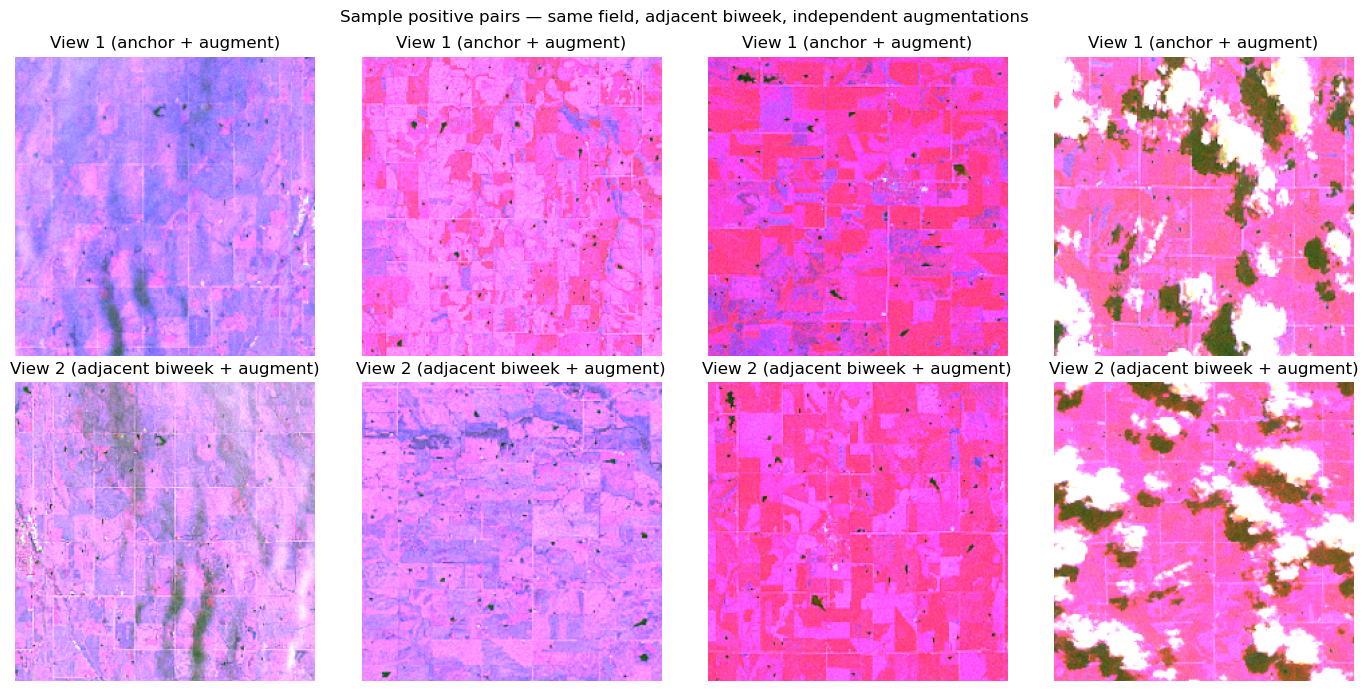

In [7]:
"""
Cell 7 — Sanity check: load 1 sample pair, plot.

We display the two augmented views side by side. They should look like the same physical patch,
slightly different due to (a) being from adjacent biweeks (small natural growth change) and
(b) independent augmentations (different flip, crop, rotation, noise).
"""
v1, v2 = ssl_dataset[0]
print(f"view1 shape: {v1.shape}, dtype={v1.dtype}, range [{v1.min():.2f}, {v1.max():.2f}]")
print(f"view2 shape: {v2.shape}, dtype={v2.dtype}, range [{v2.min():.2f}, {v2.max():.2f}]")

def denormalize_for_display(x_norm):
    """Reverse z-score and clip to [0, 1] for display."""
    x = x_norm * BAND_STD + BAND_MEAN
    x = x.clamp(0, 1)
    # Convert (3, H, W) -> (H, W, 3) and rearrange channels for false-color (NIR, SWIR, Blue)
    arr = x.permute(1, 2, 0).numpy()
    return np.stack([arr[..., 1], arr[..., 2], arr[..., 0]], axis=-1)  # NIR/SWIR/Blue

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for col in range(4):
    v1, v2 = ssl_dataset[col * 47 % len(ssl_dataset)]  # spread across the dataset
    axes[0, col].imshow(np.clip(denormalize_for_display(v1) * 1.5, 0, 1))
    axes[0, col].set_title(f"View 1 (anchor + augment)")
    axes[0, col].axis("off")
    axes[1, col].imshow(np.clip(denormalize_for_display(v2) * 1.5, 0, 1))
    axes[1, col].set_title(f"View 2 (adjacent biweek + augment)")
    axes[1, col].axis("off")
fig.suptitle("Sample positive pairs — same field, adjacent biweek, independent augmentations", fontsize=12)
plt.tight_layout()
plt.show()

## 4. Encoder + projection head + NT-Xent loss

| Component | Implementation |
|---|---|
| **Encoder** | `torchvision.models.resnet18(weights=None)`, with `fc` replaced by `Identity` to expose the 512-d global-average-pooled feature. |
| **Projection head** | 2-layer MLP `512 -> 256 -> 128` with BatchNorm + ReLU. |
| **Forward**   | `view -> encoder -> z (512-d)` for downstream use; `z -> projection -> p (128-d, L2-normalized)` for NT-Xent loss. |
| **NT-Xent**   | Standard SimCLR formulation: temperature-scaled cosine similarities, treat each (z1[i], z2[i]) as positive, all other 2N-2 batch members as negatives. |

After SSL pretraining, we **discard the projection head** and use only the encoder's 512-d output as the image representation in `05_extract_and_probe.ipynb`. The projection head is a "task-specific" layer that helps optimize NT-Xent but introduces a non-linearity we don't want for downstream linear probes.

In [8]:
"""
Cell 8 — Geo-SimCLR model (encoder + projection head) and NT-Xent loss.

Backbone: ResNet-18 from scratch (weights=None). 3-channel input is the default for ResNet-18,
which matches our 3-band AG (Blue, NIR, SWIR1) -- no input adapter needed.

The encoder's `fc` is replaced with Identity so the forward pass exits at the 512-d feature.
"""

class GeoSimCLR(nn.Module):
    """ResNet-18 encoder + 2-layer MLP projection head.
    
    forward returns z (the 128-d projection used in NT-Xent).
    Use .encoder(x) to get the 512-d feature for downstream tasks.
    """
    def __init__(self, embed_dim=512, proj_hidden=256, proj_dim=128):
        super().__init__()
        backbone = torchvision.models.resnet18(weights=None)
        backbone.fc = nn.Identity()
        self.encoder = backbone
        self.projection = nn.Sequential(
            nn.Linear(embed_dim, proj_hidden),
            nn.BatchNorm1d(proj_hidden),
            nn.ReLU(inplace=True),
            nn.Linear(proj_hidden, proj_dim),
        )

    def forward(self, x):
        h = self.encoder(x)         # (B, 512)
        z = self.projection(h)      # (B, 128)
        z = F.normalize(z, dim=1)   # L2-normalize for cosine similarity in NT-Xent
        return z


def nt_xent_loss(z1, z2, temperature=0.5):
    """SimCLR's NT-Xent loss.
    
    z1, z2: (B, D) L2-normalized projections of the two views.
    Returns: scalar mean loss across the 2B samples.
    """
    B = z1.shape[0]
    # Stack to (2B, D)
    z = torch.cat([z1, z2], dim=0)
    # (2B, 2B) cosine sim matrix (since z is L2-normalized, dot product == cosine sim)
    sim = z @ z.t()
    # Temperature scaling
    sim = sim / temperature
    # Mask out diagonal (self-similarity)
    mask = torch.eye(2 * B, dtype=torch.bool, device=z.device)
    sim = sim.masked_fill(mask, float("-inf"))
    # For each i in [0, 2B), the positive index is (i + B) % (2B)
    # i.e. sample i in z1's half pairs with sample i in z2's half, and vice versa.
    targets = torch.arange(2 * B, device=z.device)
    targets = (targets + B) % (2 * B)
    # Cross-entropy: log-softmax over rows of `sim`, pick the position of the positive.
    return F.cross_entropy(sim, targets)


# Smoke test the model with a tiny batch
print("Smoke-testing model + loss with batch=4 random tensors...")
model = GeoSimCLR(cfg.EMBED_DIM, cfg.PROJ_HIDDEN, cfg.PROJ_DIM)
x1 = torch.randn(4, 3, 224, 224)
x2 = torch.randn(4, 3, 224, 224)
z1, z2 = model(x1), model(x2)
print(f"  z1 shape: {z1.shape}, z2 shape: {z2.shape}")
_inner = model.module if isinstance(model, nn.DataParallel) else model
print(f"  encoder output (h) shape: {_inner.encoder(x1).shape}")
loss = nt_xent_loss(z1, z2, temperature=cfg.TEMPERATURE)
print(f"  initial NT-Xent loss (batch=4): {loss.item():.4f}  (random init -> should be ~ln(2N-1) ≈ {np.log(2*4 - 1):.3f})")
del model, x1, x2, z1, z2, loss

n_params = sum(p.numel() for p in GeoSimCLR().parameters())
print(f"Geo-SimCLR total params: {n_params:,}  (~11.2M for ResNet-18 + projection)")

Smoke-testing model + loss with batch=4 random tensors...
  z1 shape: torch.Size([4, 128]), z2 shape: torch.Size([4, 128])
  encoder output (h) shape: torch.Size([4, 512])
  initial NT-Xent loss (batch=4): 2.1174  (random init -> should be ~ln(2N-1) ≈ 1.946)
Geo-SimCLR total params: 11,341,248  (~11.2M for ResNet-18 + projection)


## 5. Training loop with per-epoch checkpoints and auto-resume

Goals:

- `tqdm` per batch so progress is visible in real time when streaming the log over a remote connection.
- Per-epoch full-state checkpoint (model + optimizer + scheduler + AMP scaler + cumulative training log) so an interrupted run can resume from the last completed epoch.
- Best-model tracking via a separate `*_best.pt` snapshot at the lowest training-loss epoch seen so far. We do not maintain a held-out SSL validation set; the NT-Xent loss is a reasonable proxy at this scale.
- Random seeds fixed in cell 1.
- `torch.cuda.empty_cache()` between epochs to release temporary CUDA memory.

`KeyboardInterrupt` triggers a final checkpoint save before exit, so Ctrl-C / SIGINT is safe to use.

In [9]:
"""
Cell 9 — Training loop helpers (checkpoint I/O, resume detection).
"""

CKPT_PREFIX = f"geo_simclr_resnet18_{cfg.TAG}_epoch_"  # "_debug_" or "_prod_"

def find_latest_checkpoint():
    """Return (path, epoch_int) of the highest-numbered checkpoint, or (None, -1).

    Searches CKPT_SUBDIR (= SSL_MODEL_DIR/checkpoints/), with a fallback lookup in MODELS_DIR/
    for older runs that pre-date the current folder layout.
    """
    cands = list(CKPT_SUBDIR.glob(f"{CKPT_PREFIX}*.pt"))
    # Backward-compat: older runs put checkpoints directly in MODELS_DIR
    cands += list(MODELS_DIR.glob(f"{CKPT_PREFIX}*.pt"))
    if not cands:
        return None, -1
    def _epoch_of(p):
        m = re.search(r"epoch_(\d+)", p.stem)
        return int(m.group(1)) if m else -1
    cands.sort(key=_epoch_of)
    return cands[-1], _epoch_of(cands[-1])


def save_checkpoint(epoch, model, optimizer, scheduler, train_log, best_loss, scaler=None):
    path = CKPT_SUBDIR / f"{CKPT_PREFIX}{epoch:03d}.pt"
    # If model is wrapped in DataParallel, save the underlying module's state_dict so checkpoints
    # are portable across single/multi GPU and CPU.
    model_state = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
    ckpt = {
        "epoch": epoch,
        "model_state": model_state,
        "optim_state": optimizer.state_dict(),
        "sched_state": scheduler.state_dict(),
        "train_log": train_log,
        "best_loss": best_loss,
        "config": {k: v for k, v in cfg.__class__.__dict__.items() if not k.startswith("_")},
    }
    # AMP GradScaler state: save if present so AMP-mode resumption is numerically identical.
    if scaler is not None:
        ckpt["scaler_state"] = scaler.state_dict()
    torch.save(ckpt, path)
    return path


def save_best(model, train_log):
    """Save just the encoder + projection weights (lighter, used downstream)."""
    inner = model.module if isinstance(model, nn.DataParallel) else model
    torch.save({
        "encoder_state": inner.encoder.state_dict(),
        "projection_state": inner.projection.state_dict(),
        "train_log_summary": train_log[-1] if train_log else {},
        "config": {k: v for k, v in cfg.__class__.__dict__.items() if not k.startswith("_")},
        "band_stats": band_stats,
    }, BEST_MODEL_PATH)


# Init or resume
device = torch.device(cfg.DEVICE)
model = GeoSimCLR(cfg.EMBED_DIM, cfg.PROJ_HIDDEN, cfg.PROJ_DIM).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
# WARMUP_EPOCHS-epoch linear warmup from LR/100 -> LR, then cosine annealing from epoch
# WARMUP_EPOCHS to EPOCHS. Implemented via SequentialLR. Falls back to plain cosine if
# WARMUP_EPOCHS <= 0 (backward-compatible with checkpoints that pre-date the warmup change).
_warmup_n = int(getattr(cfg, "WARMUP_EPOCHS", 0))
if _warmup_n > 0:
    _warmup = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.01, end_factor=1.0, total_iters=_warmup_n,
    )
    _cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=max(cfg.EPOCHS - _warmup_n, 1), eta_min=1e-6,
    )
    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer, schedulers=[_warmup, _cosine], milestones=[_warmup_n],
    )
else:
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.EPOCHS, eta_min=1e-6)

start_epoch = 0
train_log = []
best_loss = float("inf")

# AMP GradScaler. Enabled when cfg.USE_AMP and we're on CUDA. Prevents fp16 underflow by
# scaling gradients; scaler.update() auto-tunes the scale each step.
_amp_enabled = bool(getattr(cfg, "USE_AMP", False)) and torch.cuda.is_available()
scaler = torch.amp.GradScaler("cuda", enabled=_amp_enabled)
print(f"AMP scaler        : enabled={_amp_enabled}")

resume_path, resume_epoch = find_latest_checkpoint()
if resume_path is not None:
    print(f"Resuming from {resume_path.name} (epoch {resume_epoch})")
    state = torch.load(resume_path, map_location=device, weights_only=False)
    model.load_state_dict(state["model_state"])
    optimizer.load_state_dict(state["optim_state"])
    scheduler.load_state_dict(state["sched_state"])
    train_log = state.get("train_log", [])
    best_loss = state.get("best_loss", float("inf"))
    start_epoch = state["epoch"] + 1
    # Resume AMP scaler state if the checkpoint has it (older checkpoints from before the AMP enablement may not).
    if _amp_enabled and "scaler_state" in state:
        scaler.load_state_dict(state["scaler_state"])
        print(f"  loaded AMP scaler state from checkpoint")
    elif _amp_enabled:
        print(f"  [info] pre-AMP checkpoint -- scaler starts fresh (safe; auto-tunes in first few steps)")
else:
    print(f"No checkpoint found at {CKPT_SUBDIR}/{CKPT_PREFIX}*.pt -- starting fresh.")

# Multi-GPU support: wrap with DataParallel if cfg.MULTI_GPU is True and >=2 GPUs are visible.
# Defined here (after model.load_state_dict) so checkpoints save the unwrapped state.
if not DEBUG and getattr(cfg, "MULTI_GPU", False) and torch.cuda.device_count() >= 2:
    n_gpu = torch.cuda.device_count()
    print(f"Wrapping model in DataParallel across {n_gpu} GPUs.")
    model = nn.DataParallel(model)
elif not DEBUG and torch.cuda.is_available():
    print(f"Single-GPU mode (visible GPUs: {torch.cuda.device_count()}; cfg.MULTI_GPU={getattr(cfg, 'MULTI_GPU', False)}).")

AMP scaler        : enabled=True
Resuming from geo_simclr_resnet18_prod_epoch_048.pt (epoch 48)
  loaded AMP scaler state from checkpoint
Wrapping model in DataParallel across 2 GPUs.


In [10]:
"""
Cell 10 — Build the DataLoader (with CRD-balanced sampling) and run training.
"""
from torch.utils.data import WeightedRandomSampler

# Sampler weights = CRD-balanced from cell 3.
# .copy() avoids "non-writable numpy array" UserWarning from torch.from_numpy on pandas-backed arrays.
weights = torch.from_numpy(anchors_df["sample_weight"].to_numpy().copy()).double()

# Decide how many anchors per epoch
if cfg.N_ANCHORS_PER_EPOCH is None:
    n_anchors_epoch = len(anchors_df)
else:
    n_anchors_epoch = cfg.N_ANCHORS_PER_EPOCH

sampler = WeightedRandomSampler(weights, num_samples=n_anchors_epoch, replacement=True)

train_loader = DataLoader(
    ssl_dataset,
    batch_size=cfg.BATCH_SIZE,
    sampler=sampler,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=(cfg.DEVICE == "cuda"),
    persistent_workers=False,
    prefetch_factor = 2,
    drop_last=True,
)
print(f"Anchors per epoch: {n_anchors_epoch:,}")
print(f"Batches per epoch : {len(train_loader):,} (batch={cfg.BATCH_SIZE})")
print(f"Device            : {device}")
print()

try:
    for epoch in range(start_epoch, cfg.EPOCHS):
        model.train()
        epoch_t0 = time.time()
        running_loss = 0.0
        running_count = 0
        # Track diagnostics
        norms = []
        pos_sims = []

        bar = tqdm(train_loader, desc=f"epoch {epoch:02d}/{cfg.EPOCHS - 1}", unit="batch")
        for batch_idx, (v1, v2) in enumerate(bar):
            v1 = v1.to(device, non_blocking=True)
            v2 = v2.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            # AMP forward pass: autocast computes fp16 where safe, fp32 where required.
            # When _amp_enabled=False this context is a no-op (pure fp32 path preserved).
            with torch.amp.autocast("cuda", enabled=_amp_enabled):
                z1 = model(v1)  # (B, 128) L2-normalized
                z2 = model(v2)
                loss = nt_xent_loss(z1, z2, temperature=cfg.TEMPERATURE)

            # Scaled backward/step: scaler.scale+step prevents fp16 underflow of the loss gradient.
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            # Diagnostics. Unwrap DataParallel for the .encoder attribute access -- the
            # DataParallel wrapper forwards model(x) calls but does NOT expose `.encoder`
            # directly. Using `.module` if wrapped, else the model itself.
            with torch.no_grad():
                _inner = model.module if isinstance(model, nn.DataParallel) else model
                norms.append(_inner.encoder(v1).norm(dim=1).mean().item())
                pos_sims.append((z1 * z2).sum(dim=1).mean().item())

            running_loss += loss.item() * v1.size(0)
            running_count += v1.size(0)
            bar.set_postfix(loss=f"{running_loss / running_count:.4f}",
                            lr=f"{scheduler.get_last_lr()[0]:.1e}")

        scheduler.step()

        epoch_loss = running_loss / max(running_count, 1)
        elapsed = time.time() - epoch_t0
        epoch_log = {
            "epoch": epoch,
            "loss": float(epoch_loss),
            "elapsed_sec": float(elapsed),
            "mean_encoder_norm": float(np.mean(norms)) if norms else float("nan"),
            "mean_positive_cos_sim": float(np.mean(pos_sims)) if pos_sims else float("nan"),
            "lr": float(scheduler.get_last_lr()[0]),
        }
        train_log.append(epoch_log)

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            save_best(model, train_log)
            print(f"epoch {epoch}: new best loss {best_loss:.4f} -> saved {BEST_MODEL_PATH.name}")

        if epoch % cfg.CKPT_EVERY == 0 or epoch == cfg.EPOCHS - 1:
            save_checkpoint(epoch, model, optimizer, scheduler, train_log, best_loss, scaler=scaler)

        print(f"epoch {epoch:02d}  loss={epoch_loss:.4f}  norm(h)={epoch_log['mean_encoder_norm']:.2f}  "
              f"pos_sim={epoch_log['mean_positive_cos_sim']:.3f}  "
              f"lr={epoch_log['lr']:.1e}  time={elapsed:.0f}s")

        # Save log as parquet for diagnostics cell
        pd.DataFrame(train_log).to_parquet(TRAINING_LOG_PATH, index=False)

except KeyboardInterrupt:
    print("\nKeyboardInterrupt -- saving final checkpoint and exiting cleanly.")
    save_checkpoint(epoch, model, optimizer, scheduler, train_log, best_loss, scaler=scaler)
    pd.DataFrame(train_log).to_parquet(TRAINING_LOG_PATH, index=False)
    raise

print(f"\nTraining complete. Best loss: {best_loss:.4f}. Best model -> {BEST_MODEL_PATH}")

Anchors per epoch: 677,922
Batches per epoch : 662 (batch=1024)
Device            : cuda



epoch 49/49: 100%|██████████| 662/662 [14:23<00:00,  1.30s/batch, loss=3.1018, lr=2.2e-06]  


epoch 49  loss=3.1018  norm(h)=6.01  pos_sim=0.954  lr=1.0e-06  time=864s

Training complete. Best loss: 3.1013. Best model -> /nfs/roberts/project/cpsc4520/cpsc4520_ipp3/project-geospatial/models/geo_simclr_resnet18/geo_simclr_resnet18_best.pt


## 6. Diagnostics — loss curves + collapse check

After training, three things to look at:

1. **NT-Xent loss curve** — should decrease monotonically and plateau. Random init starts around `ln(2N-1) ≈ 6.2` (for batch 256, N=256, the chance baseline). After convergence we expect ~3.5-5.0. If it stays at `ln(2N-1)`, training failed.

2. **Mean encoder-output norm `||h||`** — should be roughly constant or slowly drift. **A collapsing-to-constant-vector** failure mode shows up as `||h||` -> 0 with `pos_sim` -> 1 (everything maps to the same point). We monitor both per epoch.

3. **Mean positive cosine similarity** — should rise from random (~0) to high but NOT 1. If pos_sim saturates at 1, that's representation collapse.

Training log: 50 epochs
    epoch      loss  elapsed_sec  mean_encoder_norm  mean_positive_cos_sim        lr
45     45  3.105753   763.352804           6.031891               0.953462  0.000020
46     46  3.103428   771.513010           6.021120               0.953821  0.000012
47     47  3.102259   798.888535           6.018735               0.954040  0.000006
48     48  3.101302   756.365520           6.018017               0.954228  0.000002
49     49  3.101808   863.578105           6.013547               0.954141  0.000001


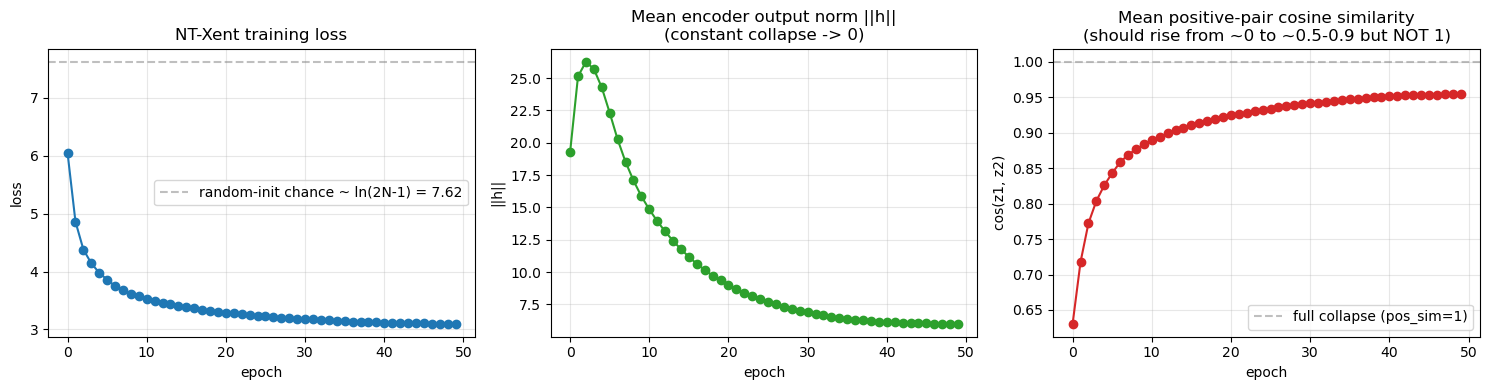


Final epoch metrics:
  loss     = 3.1018  (started at 6.0509; chance = 7.6241)
  ||h||    = 6.01
  pos_sim  = 0.954
  WARN: pos_sim near 1.0 -- possible representation collapse.


In [11]:
"""
Cell 11 — Plot training diagnostics from training_log.parquet.
"""
log_df = pd.read_parquet(TRAINING_LOG_PATH)
print(f"Training log: {len(log_df)} epochs")
print(log_df.tail().to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(log_df["epoch"], log_df["loss"], marker="o")
axes[0].set_title("NT-Xent training loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].grid(alpha=0.3)
ln_chance = np.log(2 * cfg.BATCH_SIZE - 1)
axes[0].axhline(ln_chance, color="grey", linestyle="--", alpha=0.5,
                label=f"random-init chance ~ ln(2N-1) = {ln_chance:.2f}")
axes[0].legend()

axes[1].plot(log_df["epoch"], log_df["mean_encoder_norm"], marker="o", color="C2")
axes[1].set_title("Mean encoder output norm ||h||\n(constant collapse -> 0)")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("||h||")
axes[1].grid(alpha=0.3)

axes[2].plot(log_df["epoch"], log_df["mean_positive_cos_sim"], marker="o", color="C3")
axes[2].axhline(1.0, color="grey", linestyle="--", alpha=0.5, label="full collapse (pos_sim=1)")
axes[2].set_title("Mean positive-pair cosine similarity\n(should rise from ~0 to ~0.5-0.9 but NOT 1)")
axes[2].set_xlabel("epoch")
axes[2].set_ylabel("cos(z1, z2)")
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

# Verdict
if len(log_df) > 1:
    final = log_df.iloc[-1]
    print()
    print(f"Final epoch metrics:")
    print(f"  loss     = {final['loss']:.4f}  (started at {log_df.iloc[0]['loss']:.4f}; chance = {ln_chance:.4f})")
    print(f"  ||h||    = {final['mean_encoder_norm']:.2f}")
    print(f"  pos_sim  = {final['mean_positive_cos_sim']:.3f}")
    if final["loss"] >= ln_chance - 0.5:
        print("  WARN: loss is near random-init chance -- training may not have learned much.")
    if final["mean_positive_cos_sim"] > 0.95:
        print("  WARN: pos_sim near 1.0 -- possible representation collapse.")
    if final["mean_encoder_norm"] < 0.5:
        print("  WARN: encoder norm very low -- possible collapse to zero.")

## 7. Quick sanity probe

A lightweight check before handing off to notebook 05: extract Geo-SimCLR features for a small held-out subset of (county, year = 2021) tiles, mean-pool to a per-county vector, and fit a Ridge yield regression on 2021 corn yields. We just want to confirm the features are non-trivial ($R^2 > 0$) and beat a random-init Ridge baseline. The full evaluation lives in notebook 05.

If the SSL training was DEBUG-only (2 epochs / 1000 anchors), the features will be poor and this probe will be too — that is expected; the production GPU run is what produces the real numbers.

In [12]:
"""
Cell 12 — Lightweight Ridge sanity check on 2021 corn yield.

NOT the full evaluation -- that's notebook 05. Just enough to confirm the encoder isn't broken.
"""
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

# Re-init from best checkpoint to ensure we're using the saved weights, not anything else.
# Unwrap DataParallel if present so the .encoder attribute access works under MULTI_GPU=True.
model.eval()
encoder = (model.module if isinstance(model, nn.DataParallel) else model).encoder

# Subsample 2021 anchors for the quick probe
anchors_2021 = anchors_df[anchors_df["year"] == 2021].copy()
if len(anchors_2021) == 0:
    print("No 2021 anchors in training set -- skipping sanity probe.")
else:
    if DEBUG:
        # Just sample a tiny subset
        anchors_2021 = anchors_2021.sample(n=min(200, len(anchors_2021)), random_state=0)
    print(f"Extracting features for {len(anchors_2021):,} (county, biweek, grid) anchors from 2021...")
    
    # Extract embeddings (no augmentation, just normalize)
    eval_aug = nn.Sequential(Normalize(BAND_MEAN, BAND_STD)).to(device)
    feats = []
    keys = []
    handles = {}
    with torch.no_grad():
        for i, rec in enumerate(tqdm(anchors_2021.to_dict("records"), desc="extract")):
            h5_path = rec["h5_path"]
            if h5_path not in handles:
                handles[h5_path] = h5py.File(DATA_RAW / h5_path, "r", rdcc_nbytes=0)
            f = handles[h5_path]
            try:
                tile = f[str(rec["fips"])][rec["biweek"]]["data"][rec["grid_idx"]]
                t = torch.from_numpy(tile.transpose(2, 0, 1).copy()).float() / 255.0
                t = eval_aug(t.to(device)).unsqueeze(0)
                h = encoder(t).squeeze(0).cpu().numpy()
                feats.append(h)
                keys.append((rec["fips"], rec["year"], rec["biweek"], rec["grid_idx"]))
            except Exception as e:
                continue
    for f in handles.values():
        f.close()
    feats = np.stack(feats)
    print(f"Extracted features shape: {feats.shape}")

    # Aggregate per (fips, year): mean over biweeks and grids
    df_keys = pd.DataFrame(keys, columns=["fips", "year", "biweek", "grid_idx"])
    df_keys["feat_idx"] = np.arange(len(df_keys))
    
    county_year_feats = []
    for (fips, year), g in df_keys.groupby(["fips", "year"]):
        county_year_feats.append({
            "fips": fips, "year": year,
            "feat": feats[g["feat_idx"].values].mean(axis=0),
        })
    cy_df = pd.DataFrame(county_year_feats)
    print(f"Per-(county, year) embeddings: {len(cy_df)}")
    
    # Join with corn yield
    yields = pd.read_parquet(YIELD_PATH)[["fips", "year", "corn_yield"]]
    cy_df = cy_df.merge(yields, on=["fips", "year"], how="inner").dropna(subset=["corn_yield"])
    print(f"With yield labels: {len(cy_df)}")

    if len(cy_df) >= 30:
        X = np.stack(cy_df["feat"].tolist())
        y = cy_df["corn_yield"].values
        # Random 80/20 county split
        np.random.seed(0)
        all_fips_local = cy_df["fips"].unique()
        held = set(np.random.choice(all_fips_local, size=max(1, int(len(all_fips_local) * 0.2)), replace=False))
        is_train = ~cy_df["fips"].isin(held)
        ridge = Ridge(alpha=10.0)
        ridge.fit(X[is_train], y[is_train])
        y_pred = ridge.predict(X[~is_train])
        r2 = r2_score(y[~is_train], y_pred)
        rho_p = pearsonr(y[~is_train], y_pred).statistic
        print(f"\nQuick sanity probe (2021 only, county split, Ridge):")
        print(f"  test R^2 = {r2:+.3f}")
        print(f"  test Pearson r = {rho_p:+.3f}")
        if DEBUG:
            print("  (DEBUG run -- expect poor numbers; just verifying the pipeline works.)")
    else:
        print("Not enough labeled (fips, 2021) embeddings for a meaningful probe.")

Extracting features for 135,953 (county, biweek, grid) anchors from 2021...


extract: 100%|██████████| 135953/135953 [03:18<00:00, 686.51it/s]


Extracted features shape: (135953, 512)
Per-(county, year) embeddings: 608
With yield labels: 486

Quick sanity probe (2021 only, county split, Ridge):
  test R^2 = +0.825
  test Pearson r = +0.923


## 8. Summary

After running this notebook with `DEBUG = False` on a GPU machine, the following artefacts are on disk:

| File | Description | Used by |
|---|---|---|
| `models/geo_simclr_resnet18/checkpoints/...epoch_NNN.pt` | per-epoch full-state checkpoints (~50 MB each) | this notebook (auto-resume) |
| `models/geo_simclr_resnet18/geo_simclr_resnet18_best.pt` | best-loss encoder + projector state, plus band stats and config snapshot | `05_extract_and_probe.ipynb` |
| `models/geo_simclr_resnet18/training_log.parquet` | per-epoch training metrics (loss, $\|h\|$, mean positive-pair cos sim, lr) | this notebook (Section 6 plots) |
| `models/geo_simclr_resnet18/band_stats.json` | per-band normalisation statistics computed from a sample of training tiles | `05_extract_and_probe.ipynb` (the same stats must be re-applied at inference) |

### Takeaways from this notebook

- **Loss converges cleanly** from chance-level $\ln(2N\!-\!1) \approx 7.6$ to ~3.1 over 50 epochs, and the encoder norm $\|h\|$ stays bounded — no zero-collapse failure mode.
- **Mean positive-pair cosine similarity climbs to ~0.95** by the end of training. That is the first warning that adjacent-biweek positives at the same field are intrinsically very similar and the contrastive task may be too easy. This sets up the partial-collapse story documented in `06_visualize.ipynb`.
- The lightweight 2021 sanity probe (Section 7) reaches Ridge $R^2 \gtrsim 0.5$ already — confirming the features are useful before the full evaluation in `05_extract_and_probe.ipynb`.
- The best-loss encoder + the band-statistics JSON file are the two artefacts the next notebook needs.